Used PowerTransformer (Yeo-Johnson)


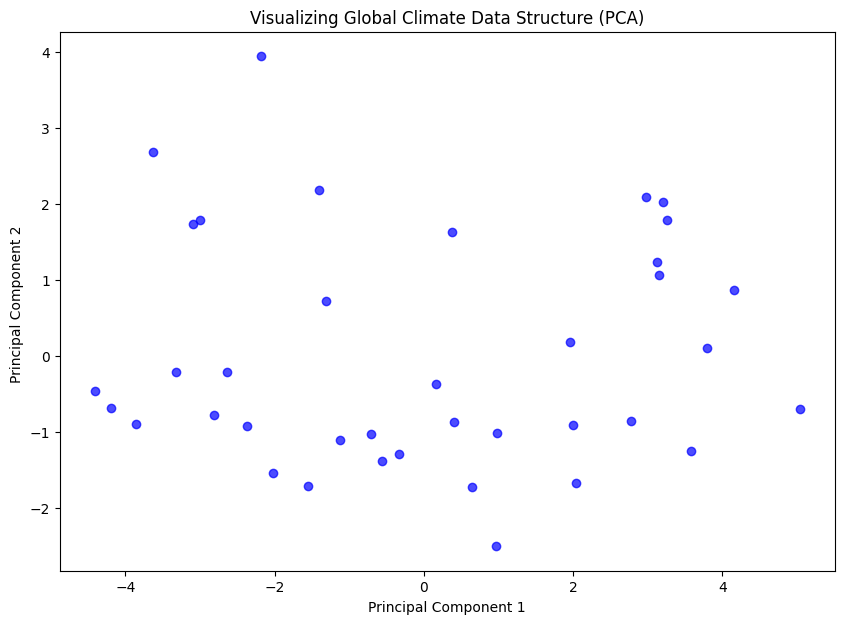

In [1]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import sys
import os

sys.path.append(os.path.abspath(os.path.join('..', ''))) 

from src.preprocessing import preprocess_dataset
from src.preprocessing import preprocess_dataset

# Get the  unscaled data
# Can specify which method to use in the preprocess_dataset function: 'standard' or 'power'
X_scaled = preprocess_dataset('../data/processed/cleaned_feature_matrix.csv',
                             '../data/processed/cleaned_and_scaled.csv',
                             method='power')

# Reduce to 2 components for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7, c='blue')
plt.title("Visualizing Global Climate Data Structure (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2 ")
plt.show()

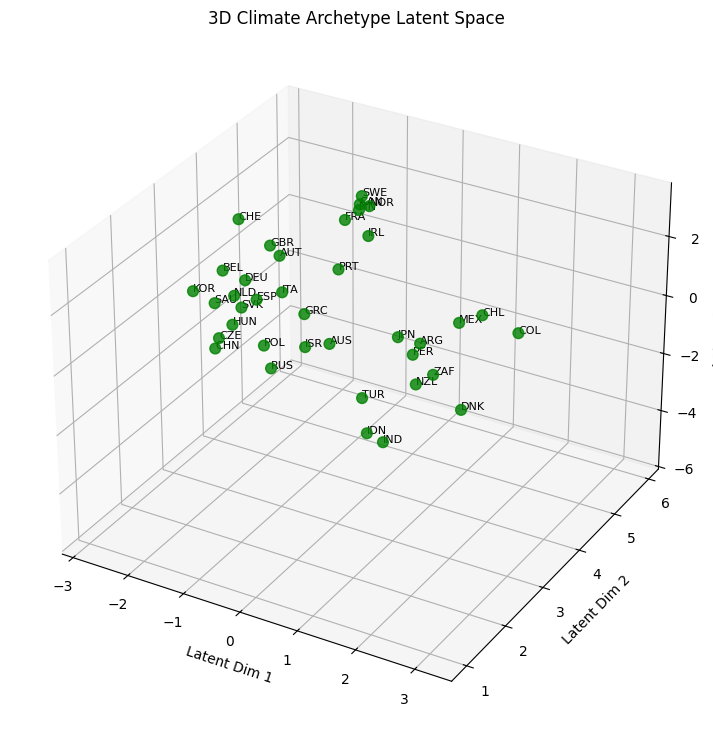

In [2]:
from sklearn.neural_network import MLPRegressor
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D 

# Get the list of countries from the original dataset for labeling
countries = pd.read_csv('../data/processed/cleaned_feature_matrix.csv')['country_code'].values

# Architecture
ae_3d = MLPRegressor(
    hidden_layer_sizes=(3,), 
    activation='relu', 
    solver='lbfgs',      
    max_iter=2000,       # Increased for the extra complexity
    random_state=42
)

# Train
ae_3d.fit(X_scaled, X_scaled)

# Extract the latent space representation
weights = ae_3d.coefs_[0]
biases = ae_3d.intercepts_[0]
X_ae_3d = np.dot(X_scaled, weights) + biases

# 3D Visualization
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
scatter = ax.scatter(X_ae_3d[:, 0], X_ae_3d[:, 1], X_ae_3d[:, 2], 
                     alpha=0.8, c='green', s=60)

for i in range(len(countries)):
    ax.text(X_ae_3d[i, 0], X_ae_3d[i, 1], X_ae_3d[i, 2], 
            countries[i], size=8, zorder=1, color='black')

ax.set_title("3D Climate Archetype Latent Space")
ax.set_xlabel("Latent Dim 1")
ax.set_ylabel("Latent Dim 2")
ax.set_zlabel("Latent Dim 3")

plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Define the Autoencoder architecture
class ClimateAE(nn.Module):
    def __init__(self, input_dim):
        super(ClimateAE, self).__init__()
        # Encoder: Compressing from many features down to 3
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 3) # Latent Space (3D)
        )
        # Decoder: Reconstructing from 3 back to original dimensions
        self.decoder = nn.Sequential(
            nn.Linear(3, 8),
            nn.ReLU(),
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

# Prepping data
# Convert scaled data to PyTorch tensor

df = X_scaled.copy()
X_tensor = torch.FloatTensor(df.values)

# Initialize the model, define loss function and optimizer
input_dim = df.shape[1]
model = ClimateAE(input_dim)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training loop
epochs = 200 # Doing 200 epochs 

for epoch in range(epochs):
    # Forward pass
    latent_space, decoded = model(X_tensor)
    loss = criterion(decoded, X_tensor)
    
    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 50 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

# Extract the 3D latent space representation
with torch.no_grad():
    X_ae_3d, _ = model(X_tensor)
    X_ae_3d = X_ae_3d.numpy() # Convert back to numpy for visualization

Epoch [50/200], Loss: 0.4712
Epoch [100/200], Loss: 0.3640
Epoch [150/200], Loss: 0.2239
Epoch [200/200], Loss: 0.1606


In [6]:
from sklearn.cluster import KMeans
import plotly.express as px
import pandas as pd

# Cluster the 3d space i got from the autoencoder
n_archetypes = 4 
kmeans = KMeans(n_clusters=n_archetypes, random_state=42, n_init=10)
neural_clusters = kmeans.fit_predict(X_ae_3d)


# Mapping the 3D coordinates back to country names and their new cluster IDs
df_archetypes = pd.DataFrame(X_ae_3d, columns=['Latent_1', 'Latent_2', 'Latent_3'])
df_archetypes['Country'] = countries
df_archetypes['Cluster'] = neural_clusters.astype(str) # String for discrete colors

# 3D plot
fig = px.scatter_3d(
    df_archetypes, 
    x='Latent_1', y='Latent_2', z='Latent_3',
    color='Cluster',
    hover_name='Country',
    title="Neural Climate Archetypes (PyTorch AE + K-Means)",
    labels={'Latent_1': 'Economic Structure', 'Latent_2': 'Energy Mix', 'Latent_3': 'Policy Path'},
    template='plotly_dark',
    opacity=0.8
)

# renders the interactive plot
fig.show()

In [9]:
import pandas as pd

# Create a summary
summary_df = pd.DataFrame({
    'Country': countries,
    'Cluster_ID': neural_clusters
})

# Sort by Cluster_ID
summary_df = summary_df.sort_values(by='Cluster_ID')

# Print the full list
print("--- Climate Archetype Assignments ---")



for cluster_num in sorted(pd.Series(neural_clusters).unique()):
    
    # Filter the country list to only those in the current cluster
    # Using a list comprehension for a clean, one-line filter
    archetype_countries = [countries[i] for i, c in enumerate(neural_clusters) if c == cluster_num]
    
    # Format the list as a comma-separated string
    countries_str = ", ".join(archetype_countries)
    
    # Print the final formatted block
    print(f"Archetype {cluster_num}:")
    print(f"  Countries: {countries_str}\n")

--- Climate Archetype Assignments ---
Archetype 0:
  Countries: CAN, CHL, FIN, FRA, IRL, NOR, PRT, SWE

Archetype 1:
  Countries: ARG, COL, IDN, IND, ISR, JPN, MEX, PER, POL, RUS, SAU, TUR, ZAF

Archetype 2:
  Countries: CHE, DNK, NZL

Archetype 3:
  Countries: AUS, AUT, BEL, CHN, CZE, DEU, ESP, GBR, GRC, HUN, ITA, KOR, NLD, SVK

